# **Load Data (1/01/2010 - 31/12/2025)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!gdown "https://drive.google.com/uc?id=196MyFoi_wohWy0uI3CgS7AokKUPw8f9H"
!gdown "https://drive.google.com/uc?id=1vAAhjQSQuOBaQAKGudGCtR3B6RKSxATA"
!gdown "https://drive.google.com/uc?id=1Fty4eeCQzBOlRd7QLgOXPwhsv0fpQ0Qp"


xauusd_df = pd.read_csv('XAUUSD_Daily_202101040000_202512300000.csv')# XAU/USD
usdthb_df = pd.read_csv('USDTHB_Daily_202101040000_202512300000.csv')# USD/THB exchange rate
vix_df = pd.read_csv('VIX_History(in).csv')# VIX index

Downloading...
From: https://drive.google.com/uc?id=196MyFoi_wohWy0uI3CgS7AokKUPw8f9H
To: /content/XAUUSD_Daily_202101040000_202512300000.csv
100% 69.8k/69.8k [00:00<00:00, 50.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vAAhjQSQuOBaQAKGudGCtR3B6RKSxATA
To: /content/USDTHB_Daily_202101040000_202512300000.csv
100% 66.6k/66.6k [00:00<00:00, 20.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Fty4eeCQzBOlRd7QLgOXPwhsv0fpQ0Qp
To: /content/VIX_History(in).csv
100% 319k/319k [00:00<00:00, 25.7MB/s]


# **1. Global Gold Log Returns ($r_{XAU}$)**
This is the baseline directional drift of the global asset.
Why it matters: It tells if the baseline asset is trending up, down, or flat.



*  **Why it matters:** It tells the HMM if the baseline asset is trending up, down, or flat.

*   **Formula:** $r_{XAU, t} = \ln(P_{XAU, t} / P_{XAU, t-1})$





In [ ]:
# 2. Prepare Datetime
xauusd_df['Datetime'] = pd.to_datetime(xauusd_df['<DATE>'], format='%Y.%m.%d')
usdthb_df['Datetime'] = pd.to_datetime(usdthb_df['<DATE>'], format='%Y.%m.%d')
xauusd_df.set_index('Datetime', inplace=True)
usdthb_df.set_index('Datetime', inplace=True)

# 3. Merge data
df = xauusd_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'XAUUSD'}).join(
    usdthb_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'USDTHB'}), how='inner'
)

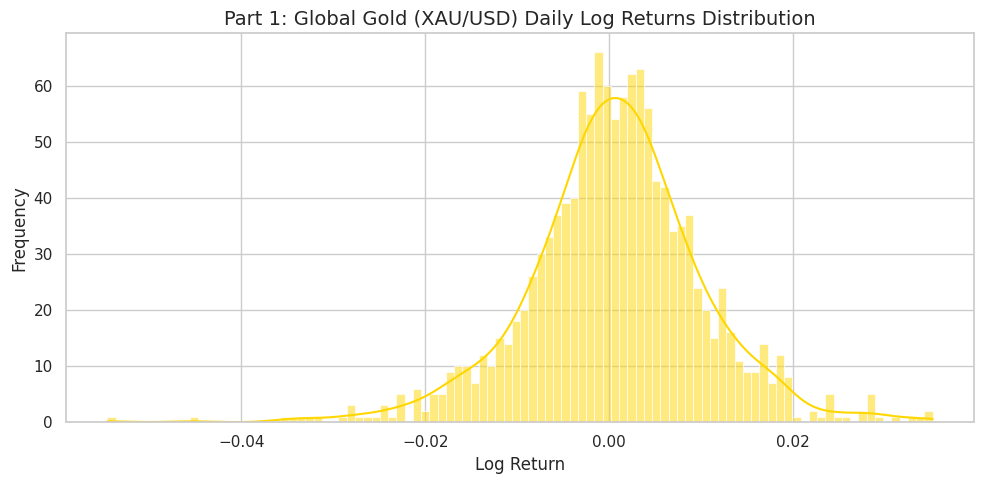

In [ ]:
# 4. Calculate Global Gold (XAU/USD) Log Returns
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# 5. Plot Log Returns Distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(df['XAU_Log_Return'].dropna(), kde=True, color='gold', bins=100)

plt.title('Part 1: Global Gold (XAU/USD) Daily Log Returns Distribution', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **2. Rolling Realized Volatility ($\sigma$)**
This is the single most important feature for an model. Market regimes are defined more by volatility than by direction.




*   **Why it matters:** Bull markets typically have low, steady volatility. Bear markets have massive, explosive volatility. Sideways markets have collapsing volatility. If you don't feed volatility to the HMM, it will fail to separate regimes.
*   **Calculation:** The standard deviation of log returns over a rolling window (e.g., 14 or 20 periods).
*   **Formula:** $\sigma_{t} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (r_{t-i} - \bar{r})^2}$




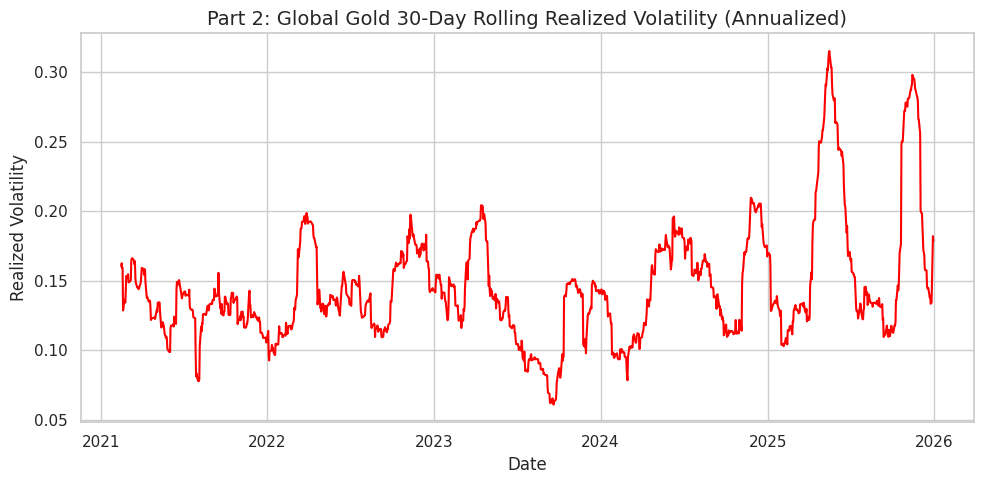

In [ ]:
# 1. Calculate 30-Day Rolling Realized Volatility (Annualized)
# Formula: 30-Day Standard Deviation of Log Returns * sqrt(252 trading days)
df['XAU_Volatility_30D'] = df['XAU_Log_Return'].rolling(window=30).std() * np.sqrt(252)

# 2. Plot Realized Volatility
plt.figure(figsize=(10, 5))

plt.plot(df.index, df['XAU_Volatility_30D'], color='red', linewidth=1.5)

plt.title('Part 2: Global Gold 30-Day Rolling Realized Volatility (Annualized)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.tight_layout()
plt.show()

# **3. USD/THB Log Returns ($r_{THB}$)**
Since you are trading Thai Gold, the currency component is mandatory.

*   **Why it matters:** If Global Gold is in a Bull regime, but the Thai Baht is rapidly appreciating (USD/THB is crashing), the Thai Gold price will flatline. The model must see this currency drift to correctly classify the local Thai regime as "Sideways" rather than "Bull."




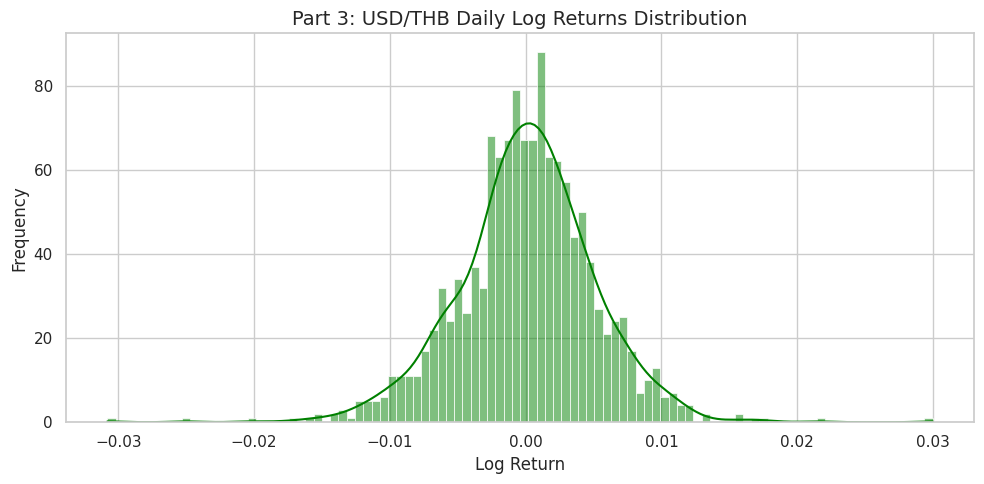

In [ ]:
# 1. Calculate USD/THB Log Returns
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# 2. Plot USD/THB Log Returns Distribution
plt.figure(figsize=(10, 5))

sns.histplot(df['THB_Log_Return'].dropna(), kde=True, color='green', bins=100)

plt.title('Part 3: USD/THB Daily Log Returns Distribution', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **4. Normalized VIX ($Z_{VIX}$) (แก้)**

Following our previous discussion, to maintain stationarity without losing the "absolute fear" context that raw log returns might obscure, use a Z-Score or a Moving Average Spread of the VIX.
* Formula: $Z_{VIX} = \frac{VIX - \mu_{VIX}}{\sigma_{VIX}}$
* Role: Acts as a leading indicator. If the VIX Z-score spikes, the Manager knows a transition to a High Volatility regime is highly probable, even before the Thai Gold price reacts.

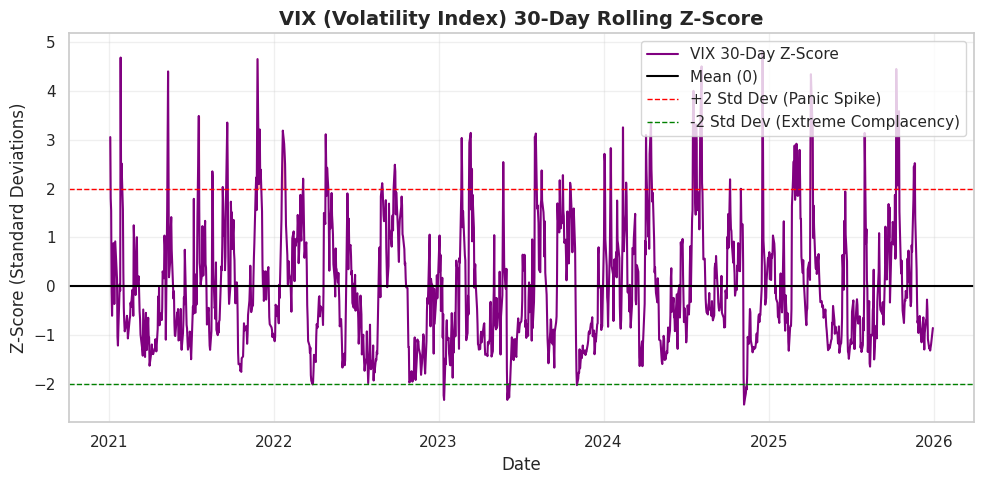

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the VIX data
vix_df = pd.read_csv("VIX_History(in).csv")

# 2. Convert DATE and sort index
vix_df['DATE'] = pd.to_datetime(vix_df['DATE'])
vix_df.set_index('DATE', inplace=True)
vix_df = vix_df.sort_index()

# ---------------------------------------------------------
# 3. Calculate 30-Day Rolling Z-Score
# ---------------------------------------------------------
# Set the rolling window size (30 days)
window = 30

# Calculate Rolling Mean and Rolling Standard Deviation
vix_df['VIX_Mean_30D'] = vix_df['CLOSE'].rolling(window=window).mean()
vix_df['VIX_Std_30D'] = vix_df['CLOSE'].rolling(window=window).std()

# Calculate Z-Score: (Current Value - Rolling Mean) / Rolling Standard Deviation
vix_df['VIX_Z_Score'] = (vix_df['CLOSE'] - vix_df['VIX_Mean_30D']) / vix_df['VIX_Std_30D']

# 4. Filter for the target timeframe (2021-2025)
vix_df_filtered = vix_df.loc['2021-01-04':'2025-12-30'].copy()

# ---------------------------------------------------------
# 5. Plot the VIX Z-Score
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot the main Z-score line
plt.plot(vix_df_filtered.index, vix_df_filtered['VIX_Z_Score'], color='purple', linewidth=1.5, label='VIX 30-Day Z-Score')

# Add statistical reference lines (+2, 0, -2)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Mean (0)')
plt.axhline(2, color='red', linestyle='--', linewidth=1, label='+2 Std Dev (Panic Spike)')
plt.axhline(-2, color='green', linestyle='--', linewidth=1, label='-2 Std Dev (Extreme Complacency)')

# Fill extreme zones for clarity (Red for panic, Green for complacency)
plt.fill_between(vix_df_filtered.index, vix_df_filtered['VIX_Z_Score'], 2,
                 where=(vix_df_filtered['VIX_Z_Score'] > 2), color='red', alpha=0.3)
plt.fill_between(vix_df_filtered.index, vix_df_filtered['VIX_Z_Score'], -2,
                 where=(vix_df_filtered['VIX_Z_Score'] < -2), color='green', alpha=0.3)

# Format the chart
plt.title('VIX (Volatility Index) 30-Day Rolling Z-Score', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Z-Score (Standard Deviations)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# **ADF test**

In [ ]:

from statsmodels.tsa.stattools import adfuller


# ---------------------------------------------------------
# 5. Run the ADF Test
# ---------------------------------------------------------
print("="*60)
print("   AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST RESULTS")
print("="*60)

for feature in clean_df.columns:
    result = adfuller(clean_df[feature])
    adf_statistic = result[0]
    p_value = result[1]

    print(f"\nFeature: {feature}")
    print(f"  ADF Statistic: {adf_statistic:.4f}")
    print(f"  p-value:       {p_value:.4e}")

    # Check if the feature passes the test (p-value < 0.05 means stationary)
    if p_value < 0.05:
        print("  Status:        ✅ STATIONARY (Safe for Modeling)")
    else:
        print("  Status:        ❌ NON-STATIONARY (Requires Transformation)")

print("\n" + "="*60)

   AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST RESULTS

Feature: XAU_Log_Return
  ADF Statistic: -35.5629
  p-value:       0.0000e+00
  Status:        ✅ STATIONARY (Safe for Modeling)

Feature: THB_Log_Return
  ADF Statistic: -13.6521
  p-value:       1.5788e-25
  Status:        ✅ STATIONARY (Safe for Modeling)

Feature: VIX_Z_Score
  ADF Statistic: -10.3832
  p-value:       2.1131e-18
  Status:        ✅ STATIONARY (Safe for Modeling)

Feature: XAU_Volatility_30D
  ADF Statistic: -5.2048
  p-value:       8.5948e-06
  Status:        ✅ STATIONARY (Safe for Modeling)

Feature: ThaiGold_Log_Return
  ADF Statistic: -36.1645
  p-value:       0.0000e+00
  Status:        ✅ STATIONARY (Safe for Modeling)



# **why not feeding raw data?**
**1. The "Stationarity" Problem (Eradicating Trend)**

  Machine learning models are essentially pattern-matching engines. They rely on the assumption that the data they are trained on will look mathematically similar to the data they predict in the future.

* Raw Data is "Non-Stationary": Prices drift over time. Imagine you train an AI on Thai Gold from 2015–2020, when the price fluctuated around 20,000 THB. If you ask that AI to predict the market today at 40,000 THB, the model will break. It has never seen the number "40,000" and doesn't know what to do.

* The Log Return / ROC Fix: Both of these metrics measure percentage change, not absolute price. A +2% daily jump looks exactly the same mathematically whether Gold is at 20,000 THB or 100,000 THB. These metrics oscillate consistently around a stable mean (usually 0%), making the data stationary. The AI learns the behavior of the market rather than memorizing price levels.

**2. The Magnitude and Scaling Illusion**

  AI models (like Neural Networks, SVMs, and K-Means) use mathematical distance to calculate how "important" a feature is.

* The Raw Data Trap: In your dataset, International Gold is around 4,000, the USD/THB exchange rate is 32, and the VIX is 15. If you feed this into a model, the algorithm will naturally assume Gold is hundreds of times more "important" than the VIX simply because the number 4,000 is bigger than 15.

* The Log Return / ROC Fix: Converting everything to percentages levels the playing field. A 1% move in Gold becomes 0.01. A 1% move in the VIX becomes 0.01. This forces the AI to look at the actual statistical relationship rather than being tricked by the sheer size of the numbers.

**3. Capturing True Momentum (Why ROC is powerful)**
Raw prices only tell you where an asset is. They tell you nothing about how fast it is moving.

* If Gold is at $2,000, is that a good thing or a bad thing? The AI doesn't know unless it looks backward.

* Rate of Change (ROC) acts as a pure momentum gauge. A 14-Day ROC of +5% explicitly tells the AI: "This asset is accelerating upward right now." Machine learning models are incredibly good at predicting future price directions when you feed them the speed and acceleration of the asset, rather than just its current location.

**4. Mathematical Symmetry (Why Log Returns are magical)**
Standard percentages (and raw prices) have a hidden mathematical flaw.

* If you have $100 and it goes up by normal 10%, you have $110.

* If it then goes down by normal 10%, you drop to $99.

* You did not get back to your starting point! This asymmetry deeply confuses predictive algorithms over long periods.

* Log Returns are perfectly symmetrical. A log return of +0.05 followed by a log return of -0.05 leaves you at the exact same starting value. Furthermore, if you want to know the weekly return, you can simply add the 5 daily log returns together. This elegant math makes it vastly easier for an AI to optimize its weights and biases without error.

# **Heat map (แก้)**

# **Explaiantion why low value in heatmap is still relate as a feature**
**1. The Limitation of Pearson Correlation (Linear vs. Non-Linear Dynamics)**

* The standard correlation heatmap relies on the Pearson correlation coefficient, which exclusively measures linear dependence (e.g., "For every 1% increase in X, Y increases by exactly 0.5%"). However, financial markets are inherently complex and non-linear.
As demonstrated by Mutual Information (MI) scores and LOWESS (Locally Weighted Scatterplot Smoothing) curves, the relationship between stock market fear (VIX) and Gold is non-linear. By discarding features solely based on Pearson scores, a model is forced to assume the market is perfectly linear, resulting in critical blind spots.

**2. The "Threshold" and Asymmetric Effect of the VIX**
* The VIX (Volatility Index) does not have a 1:1 daily relationship with Gold under normal market conditions. If the 14-Day VIX ROC moves by a normal +5% or -5%, Gold generally does not react, which drives the linear correlation toward zero.
However, the VIX operates on a Threshold Effect. When the VIX experiences an extreme, violent spike (e.g., a +40% ROC indicating a global equity sell-off or black swan event), a sudden "flight to safety" occurs, driving capital massively into safe-haven assets like Gold. If the VIX feature is removed, the predictive model will be completely blind to these rare, asymmetric market crashes where the most violent price movements in Gold actually occur.

**3. Realized Volatility as a "Regime" Indicator (State Variable)**
* The 30-Day Realized Volatility of Gold measures the magnitude of recent price swings, not the direction. Therefore, its direct correlation to daily returns is naturally zero. You can have high volatility during a massive bull run or a massive crash.
Instead of predicting direction, Realized Volatility acts as a State Variable that identifies the current "Market Regime."

* In a low-volatility regime, Thai Gold might be heavily driven by standard USD/THB currency fluctuations.

* In a high-volatility regime, the currency effect might be entirely overpowered by institutional panic-buying of international gold.
Advanced algorithms (like Random Forests or XGBoost) use volatility as a root-node splitter to ask: "What state is the market in right now?" before applying other predictive rules.

**4. Conditional Dependence in Machine Learning**

In modern Machine Learning, a feature with zero independent correlation can become highly predictive when combined with other features—a concept known as Conditional Dependence.
For example, the AI might discover a complex interaction rule:

* IF the US Dollar is weakening (THB strengthening) AND Gold Volatility is abnormally low AND the VIX is suddenly accelerating... THEN a breakout in Thai Gold is highly probable. If you drop the VIX and Volatility features just because they look weak on a simple 2D heatmap, you mathematically prevent the algorithm from discovering these multi-dimensional, high-probability trade setups.

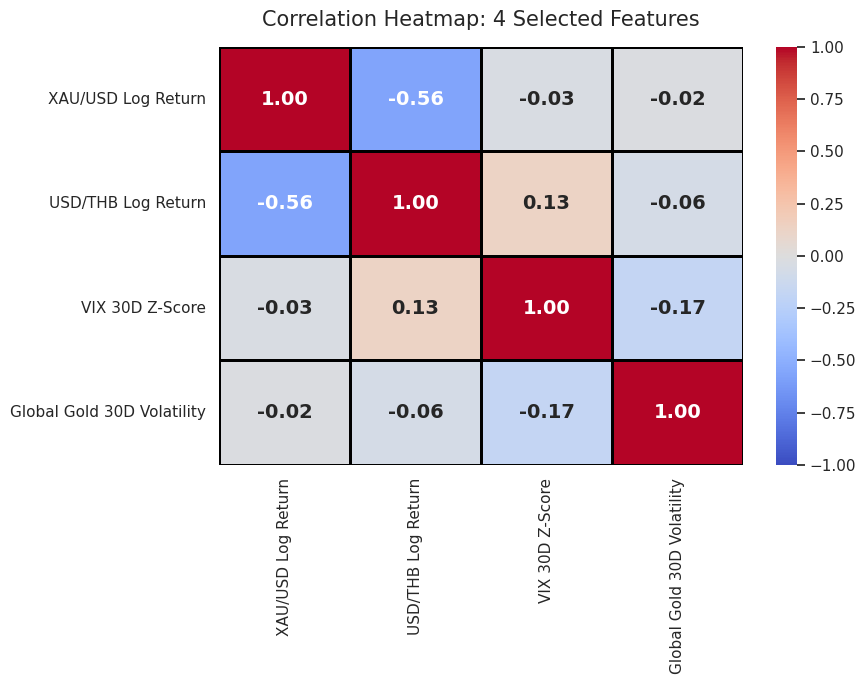

In [ ]:
# 4. Calculate The 4 Features
# ---------------------------------------------------------
# Feature 1: XAU/USD Log Return
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# Feature 2: USD/THB Log Return
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# Feature 3: VIX 30-Day Z-Score
vix_mean = df['VIX'].rolling(window=30).mean()
vix_std = df['VIX'].rolling(window=30).std()
df['VIX_Z_Score'] = (df['VIX'] - vix_mean) / vix_std

# Feature 4: Global Gold 30D Rolling Realized Volatility
df['XAU_Volatility_30D'] = df['XAU_Log_Return'].rolling(window=30).std() * np.sqrt(252)

# Subset into a clean DataFrame (Drop NaN values created by rolling windows)
features_df = df[['XAU_Log_Return', 'THB_Log_Return', 'VIX_Z_Score', 'XAU_Volatility_30D']].dropna().copy()
features_df.columns = ['XAU/USD Log Return', 'USD/THB Log Return', 'VIX 30D Z-Score', 'Global Gold 30D Volatility']

# ---------------------------------------------------------
# 5. Generate Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(9, 7))

sns.heatmap(features_df.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=1, linecolor='black', vmin=-1, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Correlation Heatmap: 4 Selected Features', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

# **Summarization of heat map relationships (แก้)**
**1. The "Tug of War" (Strong Negative Relationship)**
Features: XAU/USD Log Return vs. USD/THB Log Return (-0.56)

* The Relationship: This is the only strong linear relationship on the entire board. It is a solid negative correlation.

* What it means: When International Gold goes up, the USD/THB exchange rate tends to go down (meaning the Thai Baht gets stronger). This happens because Gold is priced in US Dollars. If Gold is having a great day, it usually means the US Dollar is having a fundamentally weak day globally—which naturally makes the Baht stronger against it.

**2. The "Chaos vs. Direction" Divide (Zero Correlation)**
Features: Global Gold 30D Volatility vs. XAU/USD Log Return (-0.02) & USD/THB Log Return (-0.06)

* The Relationship: Almost absolute zero. There is no linear relationship between how volatile the market is and which direction the price moves.

* What it means: A common beginner mistake is assuming "High Volatility = Price Crash." The heatmap mathematically proves this is false for Gold. You can have a month of extreme 30-Day Volatility where Gold crashes, and a month of extreme Volatility where Gold skyrockets. Volatility strictly measures the size of the daily swings, not the direction of the trend.

**3. The "Isolated Fear" (Independence)**
Features: VIX 30D Z-Score vs. XAU/USD Log Return (-0.03) & USD/THB Log Return (+0.08)

* The Relationship: Completely neutral/independent.

* What it means: The VIX Z-Score tells us when the US Stock Market is experiencing an extreme, abnormal panic attack. However, the heatmap proves that on a day-to-day basis, US stock market panic does not consistently drive Gold prices up or down, nor does it reliably move the Thai Baht. They operate in largely disconnected environments.

**4. The "Different Flavors of Chaos" (Weak Relationship)**
Features: VIX 30D Z-Score vs. Global Gold 30D Volatility (-0.14)

* The Relationship: Very weak negative correlation.

* What it means: Even the two "chaos" metrics don't agree with each other! You would think that if the stock market is highly volatile (High VIX), the Gold market would also be highly volatile. The heatmap shows this is mostly false. Gold traders and Stock traders panic over completely different news events and at different times.










# **Pair plot (แก้)**

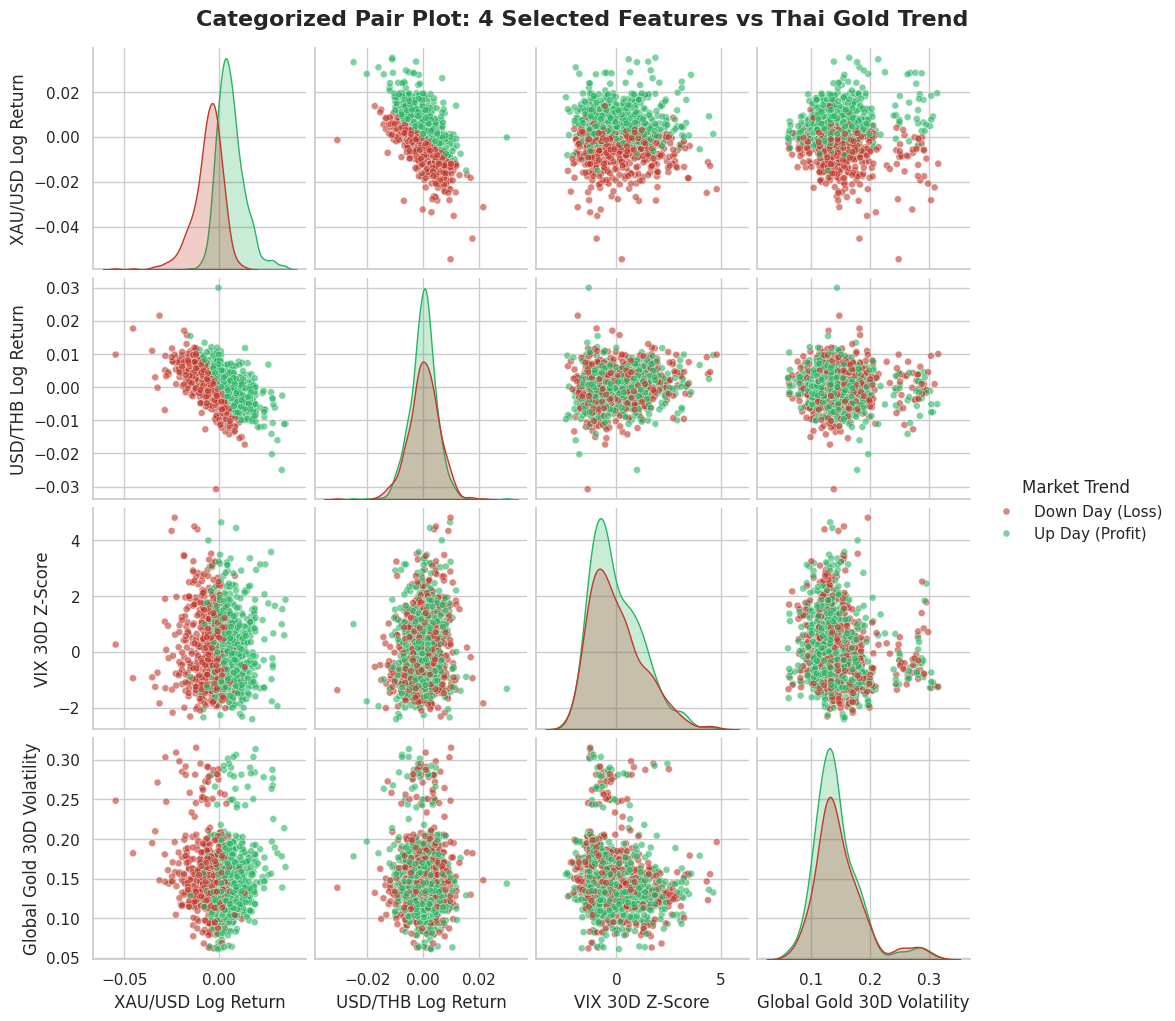

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
xauusd_df = pd.read_csv("XAUUSD_Daily_202101040000_202512300000.csv")
usdthb_df = pd.read_csv("USDTHB_Daily_202101040000_202512300000.csv")
vix_df = pd.read_csv("VIX_History(in).csv")

# 2. Format Datetime and set index
xauusd_df['Datetime'] = pd.to_datetime(xauusd_df['<DATE>'], format='%Y.%m.%d')
usdthb_df['Datetime'] = pd.to_datetime(usdthb_df['<DATE>'], format='%Y.%m.%d')
vix_df['Datetime'] = pd.to_datetime(vix_df['DATE'])

xauusd_df.set_index('Datetime', inplace=True)
usdthb_df.set_index('Datetime', inplace=True)
vix_df.set_index('Datetime', inplace=True)
vix_df.sort_index(inplace=True)

# 3. Merge datasets matching dates
df = xauusd_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'XAUUSD'}).join(
    usdthb_df[['<CLOSE>']].rename(columns={'<CLOSE>': 'USDTHB'}), how='inner'
).join(
    vix_df[['CLOSE']].rename(columns={'CLOSE': 'VIX'}), how='inner'
)

# ---------------------------------------------------------
# 4. Calculate The Features
# ---------------------------------------------------------
# Feature 1: XAU/USD Log Return
df['XAU_Log_Return'] = np.log(df['XAUUSD'] / df['XAUUSD'].shift(1))

# Feature 2: USD/THB Log Return
df['THB_Log_Return'] = np.log(df['USDTHB'] / df['USDTHB'].shift(1))

# Feature 3: VIX 30-Day Z-Score
vix_mean = df['VIX'].rolling(window=30).mean()
vix_std = df['VIX'].rolling(window=30).std()
df['VIX_Z_Score'] = (df['VIX'] - vix_mean) / vix_std

# Feature 4: Global Gold 30D Rolling Realized Volatility
df['XAU_Volatility_30D'] = df['XAU_Log_Return'].rolling(window=30).std() * np.sqrt(252)

# Calculate Thai Gold Return for the Categorization (Hue)
weight_ratio = 15.244 / 31.1034768
purity = 0.965
multiplier = weight_ratio * purity
df['ThaiGoldPrice'] = df['XAUUSD'] * df['USDTHB'] * multiplier
df['ThaiGold_Log_Return'] = np.log(df['ThaiGoldPrice'] / df['ThaiGoldPrice'].shift(1))

# ---------------------------------------------------------
# 5. Clean and Structure DataFrame for the Pairplot
# ---------------------------------------------------------
# Drop NaN values created by rolling windows
features_cols = ['XAU_Log_Return', 'THB_Log_Return', 'VIX_Z_Score', 'XAU_Volatility_30D', 'ThaiGold_Log_Return']
clean_df = df[features_cols].dropna().copy()

# Setup DataFrame strictly for the plot
plot_df = pd.DataFrame()
plot_df['XAU/USD Log Return'] = clean_df['XAU_Log_Return']
plot_df['USD/THB Log Return'] = clean_df['THB_Log_Return']
plot_df['VIX 30D Z-Score'] = clean_df['VIX_Z_Score']
plot_df['Global Gold 30D Volatility'] = clean_df['XAU_Volatility_30D']

# Create Categorical Variable for the 'hue' parameter
plot_df['Market Trend'] = np.where(clean_df['ThaiGold_Log_Return'] > 0, 'Up Day (Profit)', 'Down Day (Loss)')

# ---------------------------------------------------------
# 6. Generate Pairplot with Color Categories
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

pairplot = sns.pairplot(plot_df, hue='Market Trend',
                        palette={'Up Day (Profit)': '#28B463', 'Down Day (Loss)': '#C0392B'},
                        kind='scatter', diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 25})

pairplot.fig.suptitle('Categorized Pair Plot: 4 Selected Features vs Thai Gold Trend', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# **Summarization of pairplot relationships(เพิ่ม)**
**1. The "Perfect Split" (Predictive Power)**
Feature: XAU/USD Log Return

* What the chart shows: If you look at the density curve (the hills on the diagonal) or any scatter plot involving XAU/USD, there is a massive separation of colors. The Green dots/curves are almost entirely on the right side (positive numbers), and the Red dots/curves are on the left side (negative numbers).

* The Summary: International Gold is the absolute dictator of Thai Gold. If you want to predict whether tomorrow will be a green day or a red day, XAU/USD is doing 95% of the heavy lifting.

**2. The "Tilted Cloud" (Negative Correlation)**
Features: XAU/USD Log Return vs. USD/THB Log Return

* What the chart shows: A distinct oval cloud that tilts downward from top-left to bottom-right. Additionally, looking at the USD/THB density curve, the Red curve is shifted slightly to the right (higher exchange rate), and the Green curve is shifted slightly to the left.

* The Summary: They actively fight each other. When Gold goes up (moving right), the US Dollar gets weaker globally, causing the USD/THB exchange rate to drop (moving down). This visualizes the "shock absorber" effect—it is mathematically rare to get a massive gold rally and a weakening Baht on the exact same day.

**3. The "Messy Circles" (Independence)**
Features: VIX 30D Z-Score & Global Gold 30D Volatility vs. Everything Else

* What the chart shows: Perfect, scattered circles that look like shotgun blasts. There is no upward or downward tilt when these features are plotted against Gold or the Exchange Rate.

* The Summary: There is no linear relationship here. A high VIX Z-Score (stock market panic) does not automatically mean gold will go up today, nor does it mean it will go down. They operate on completely independent mathematical planes.

**4. The "Overlapping Hills" (Magnitude vs. Direction)**
Features: VIX Z-Score & Global Gold Volatility Density Curves (The Diagonals)

* What the chart shows: Look at the diagonal density plots for the VIX and Gold Volatility. The Green curve and the Red curve are stacked almost exactly on top of each other.

* The Summary: This is a crucial lesson for Machine Learning: Volatility does not predict direction. * You can have a day with massive 30-day Gold Volatility where you make a fortune (Green).

You can have a day with massive 30-day Gold Volatility where you lose a fortune (Red).

Volatility and VIX only tell the model that the market is chaotic and the swings will be large, but they cannot tell the model which way the price will swing.